# 붓꽃 데이터 차원 축소

## 1. 패키지 설정

In [39]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. iris 데이터세트 읽기

In [40]:
data = datasets.load_iris()

In [41]:
# data 부분에 있는 feature_names을 열 이름으로 하는 데이터 프레임 생성
df = pd.DataFrame(data['data'], columns=data['feature_names'])
# target 부분의 데이터를 데이터 프레임에 열로 추가
df['target'] = data['target']
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. 탐색적 데이터 분석

<Figure size 800x800 with 0 Axes>

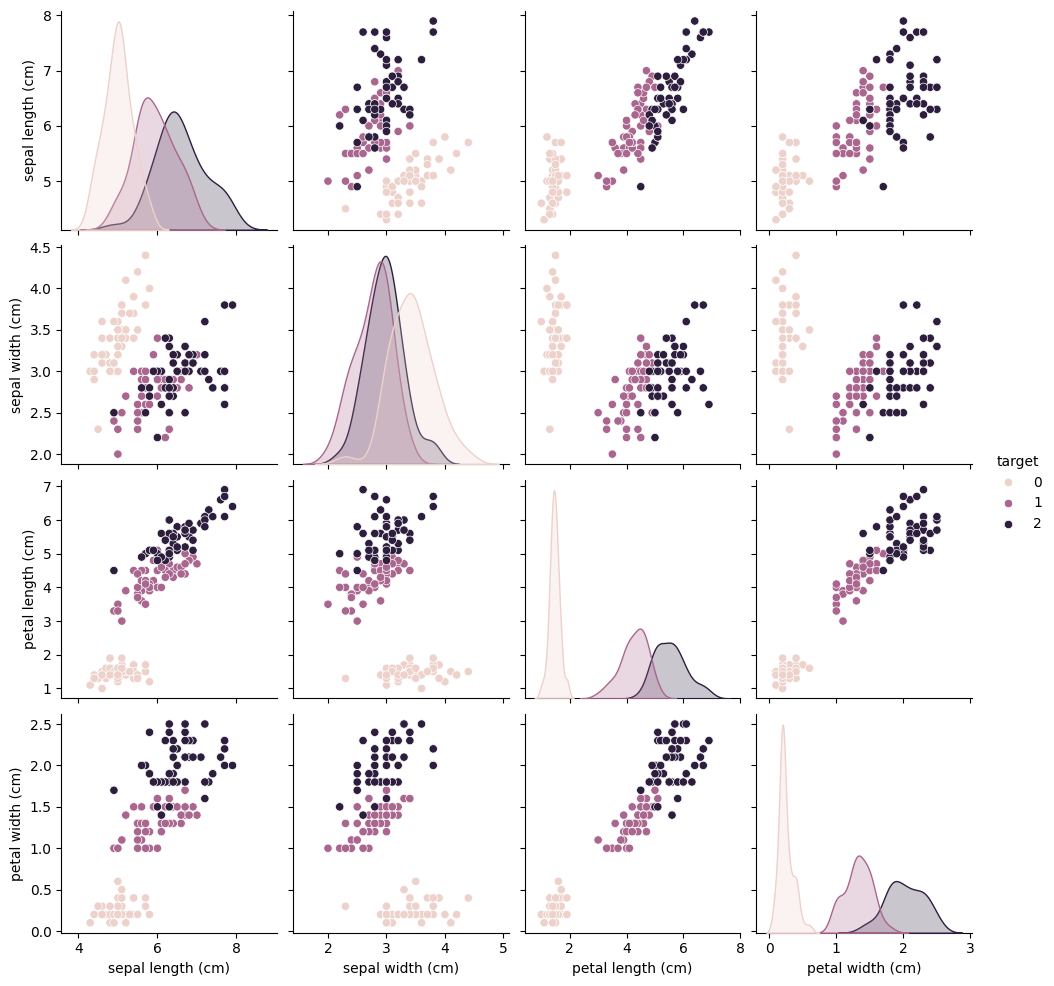

In [42]:
# 그래프 출력
plt.figure(figsize=(8, 8))
ax = sns.pairplot(df, hue='target')
plt.show()

In [43]:
X_df = df.iloc[:, :4]
# 열별 평균 및 분산
print(X_df.mean(axis=0))
print(X_df.var(axis=0))

sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


## 5. 데이터 표준화

In [44]:
scalerX = StandardScaler()
scalerX.fit(data.data)
X_std = scalerX.transform(data.data)

## 5. 주성분 분석 객체 생성

In [45]:
pca = PCA() # (PCA(n_components=4))와 동일
pca.fit(X_std)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [46]:
print(pca.explained_variance_) # 주성분 분산
print(pca.explained_variance_ratio_) # 주성분 분산비율

[2.93808505 0.9201649  0.14774182 0.02085386]
[0.72962445 0.22850762 0.03668922 0.00517871]


Text(0, 0.5, 'Variance')

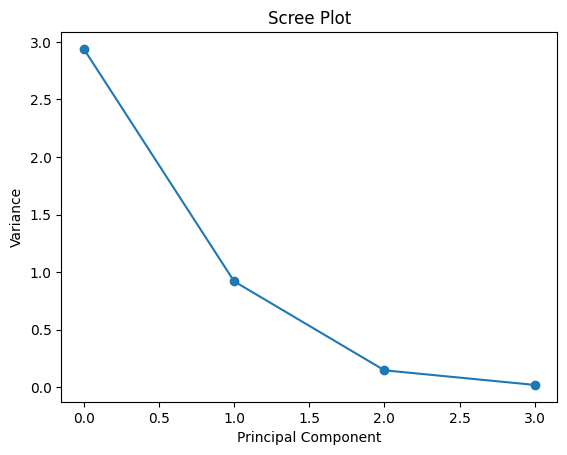

In [47]:
# Scree Plot (주성분 분산 그래프)
plt.plot(pca.explained_variance_, 'o-')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance')

## 6. 주성분으로 데이터 변환

In [48]:
Z = pca.fit_transform(X_std) # 주성분으로 데이터 변환
Z_df = pd.DataFrame(data=Z, columns=['PC1', 'PC2', 'PC3', 'PC4']) 
Z_df.head()

,PC1,PC2,PC3,PC4
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923


In [49]:
# target 열 추가
Z_df['target'] = data['target']

<Figure size 800x800 with 0 Axes>

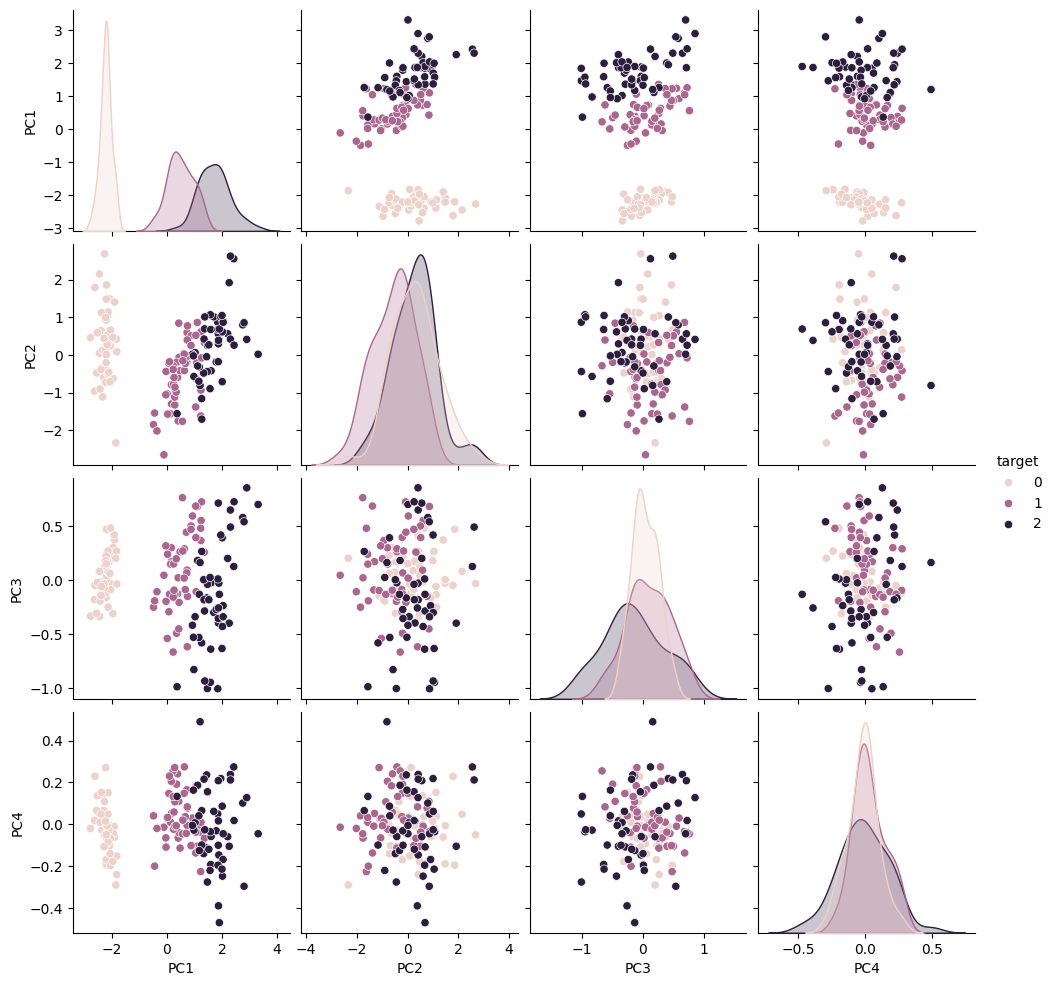

In [50]:
# 그래프 출력
plt.figure(figsize=(8, 8))
ax = sns.pairplot(Z_df, hue='target') 
plt.show()

## 7. 주성분 로딩

In [51]:
loadings = pca.components_
print(loadings)

[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]


## 8. 그래프 표시

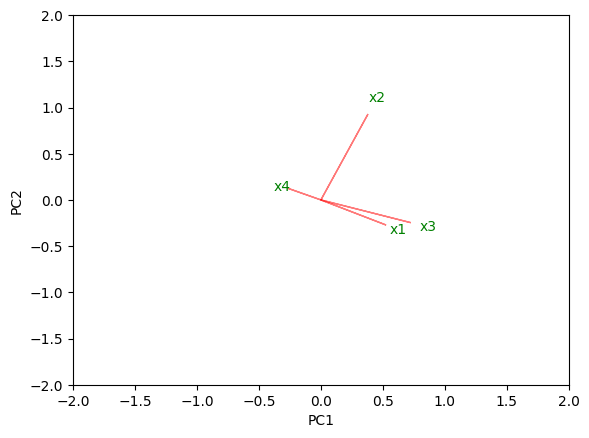

In [52]:
# 주성분 로딩 분포: PC1, PC2 관점
plt.scatter(loadings[:,0], loadings[:,1], color='w')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

# 행과 열의 수 및 행의 이름 설정
rows, columns = loadings.shape
rows_names = ['x1', 'x2', 'x3', 'x4']
for i in range(rows):
    # 선 긋기
    plt.arrow(0, 0, loadings[i,0], loadings[i,1], color='r', alpha=0.5)
    # 변수명 출력
    plt.text(loadings[i,0]*1.2, loadings[i,1]*1.2, rows_names[i], color='g', ha='center', va='center')

## 9. KNN 모형화 및 학습

### 9-1. 필요 함수 정의

In [53]:
# K값에 따른 분류 정확도 계산
def knn_accuracy(X, y, neighbors):
    accuracy = [] # 데이터 분류 정확도

    # 최근접 이웃의 수
    for k in neighbors:
        knn = KNeighborsClassifier(n_neighbors=k) # 모형화
        knn.fit(X, y) # 학습

        # 분류 정확도 저장
        score = knn.score(X, y)
        accuracy.append(score)
    
    return accuracy

# K값에 따른 분류 정확도 출력 및 그래프 표시
def show_accuracy(neighbors, accuracy):
    plt.plot(neighbors, accuracy, label="accuracy")
    plt.xlabel("K")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
    # k별 정확도 출력
    for k, score in enumerate(accuracy):
        print(f"k {k + 1}: {score}")

### 9-2. 기본 데이터 학습

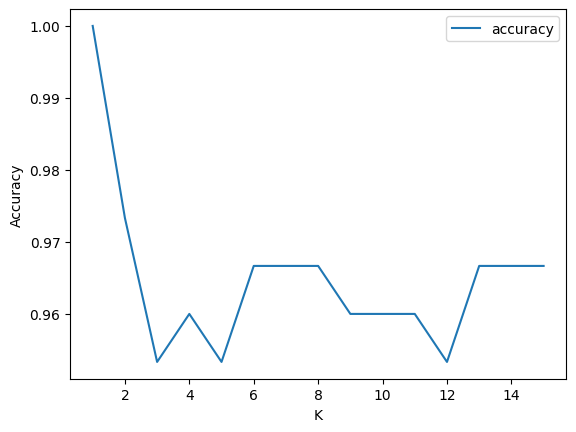

k 1: 1.0
k 2: 0.9733333333333334
k 3: 0.9533333333333334
k 4: 0.96
k 5: 0.9533333333333334
k 6: 0.9666666666666667
k 7: 0.9666666666666667
k 8: 0.9666666666666667
k 9: 0.96
k 10: 0.96
k 11: 0.96
k 12: 0.9533333333333334
k 13: 0.9666666666666667
k 14: 0.9666666666666667
k 15: 0.9666666666666667


In [54]:
neighbors = range(1,16)
origin_accuracy = knn_accuracy(X_std, data.target, neighbors)
show_accuracy(neighbors, origin_accuracy)


### 9-2. PCA 적용 데이터 학습

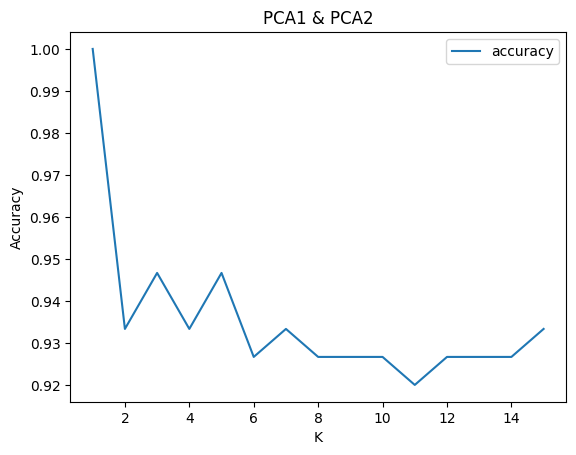

k 1: 1.0
k 2: 0.9333333333333333
k 3: 0.9466666666666667
k 4: 0.9333333333333333
k 5: 0.9466666666666667
k 6: 0.9266666666666666
k 7: 0.9333333333333333
k 8: 0.9266666666666666
k 9: 0.9266666666666666
k 10: 0.9266666666666666
k 11: 0.92
k 12: 0.9266666666666666
k 13: 0.9266666666666666
k 14: 0.9266666666666666
k 15: 0.9333333333333333


In [55]:
Z_selected_1_2 = Z[:, :2]
Z_selected_1_3 = Z[:, [0, 2]]
pca_accuracy = knn_accuracy(Z_selected_1_2, data.target, neighbors)
plt.title("PCA1 & PCA2")
show_accuracy(neighbors, pca_accuracy)

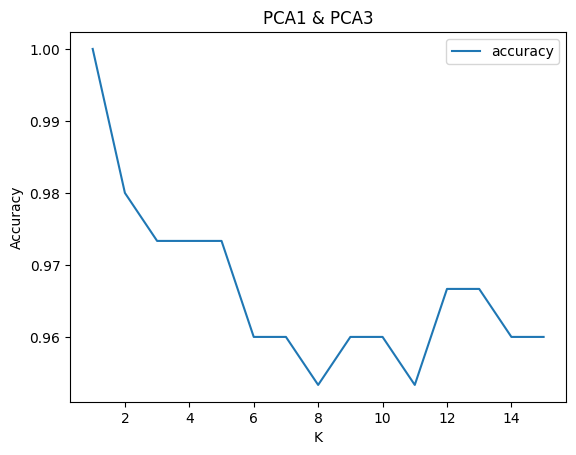

k 1: 1.0
k 2: 0.98
k 3: 0.9733333333333334
k 4: 0.9733333333333334
k 5: 0.9733333333333334
k 6: 0.96
k 7: 0.96
k 8: 0.9533333333333334
k 9: 0.96
k 10: 0.96
k 11: 0.9533333333333334
k 12: 0.9666666666666667
k 13: 0.9666666666666667
k 14: 0.96
k 15: 0.96


In [56]:
pca_accuracy = knn_accuracy(Z_selected_1_3, data.target, neighbors)
plt.title("PCA1 & PCA3")
show_accuracy(neighbors, pca_accuracy)